# Gradient Boosting and XGBoost

### Importing packages

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
import sklearn
from sklearn import tree
import matplotlib.pyplot as plt

### Plotting functions

In [2]:
# Some functions to plot our points and draw the lines
def plot_points(features, labels, fix_margins=True):
    X = np.array(features)
    y = np.array(labels)
    spam = X[np.argwhere(y==1)]
    ham = X[np.argwhere(y==0)]
    if fix_margins:
        plt.xlim(0, 11)
        plt.ylim(0, 11)
    plt.scatter([s[0][0] for s in spam],
                [s[0][1] for s in spam],
                s = 100,
                color = 'cyan',
                edgecolor = 'k',
                marker = '^')
    plt.scatter([s[0][0] for s in ham],
                [s[0][1] for s in ham],
                s = 100,
                color = 'red',
                edgecolor = 'k',
                marker = 's')
    plt.xlabel('Lottery')
    plt.ylabel('Sale')
    plt.legend(['Spam','Ham'])

def plot_model(X, y, model, fix_margins=True):
    X = np.array(X)
    y = np.array(y)
    plot_points(X, y)
    plot_step = 0.01
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    if fix_margins:
        x_min=0
        y_min=0
        x_max=12
        y_max=12
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, colors=['red', 'blue'], alpha=0.2, levels=range(-1,2))
    plt.contour(xx, yy, Z,colors = 'k',linewidths = 3)
    plt.show()

def display_tree(dt):
    import matplotlib.pyplot as plt
    from sklearn.tree import plot_tree

    plt.figure(figsize=(12, 8))
    plot_tree(
        dt,
        filled=True,
        rounded=True
    )
    plt.show()

def plot_regressor(model, features, labels):
    x = np.linspace(0,85,1000)
    plt.scatter(features, labels)
    plt.plot(x, model.predict(x.reshape([-1,1])))
    plt.xlabel("Age")
    plt.ylabel("Days per week")
    plt.show()

### The dataset

In [3]:
features = np.array([[10],[20],[30],[40],[50],[60],[70],[80]])
labels = np.array([7,5,7,1,2,1,5,4])

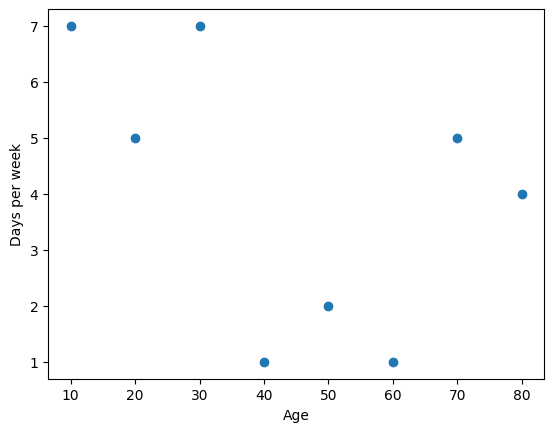

In [4]:
plt.scatter(features, labels)
plt.xlabel("Age")
plt.ylabel("Days per week")
plt.show()

# Fitting a decision tree

In [5]:
decision_tree_regressor = DecisionTreeRegressor(max_depth=2) #for regression prediction
decision_tree_regressor.fit(features, labels)

DecisionTreeRegressor(max_depth=2)

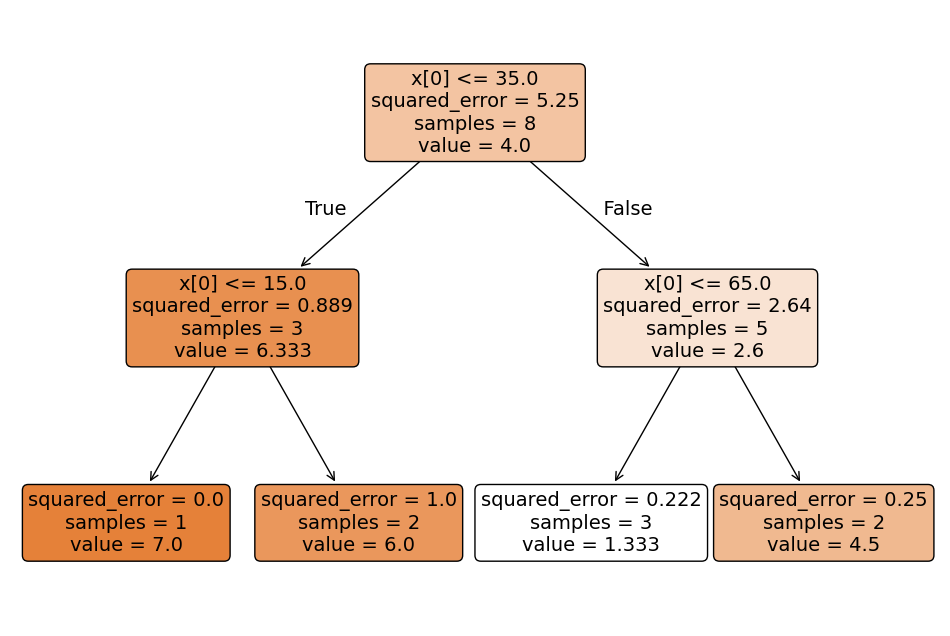

In [6]:
display_tree(decision_tree_regressor)

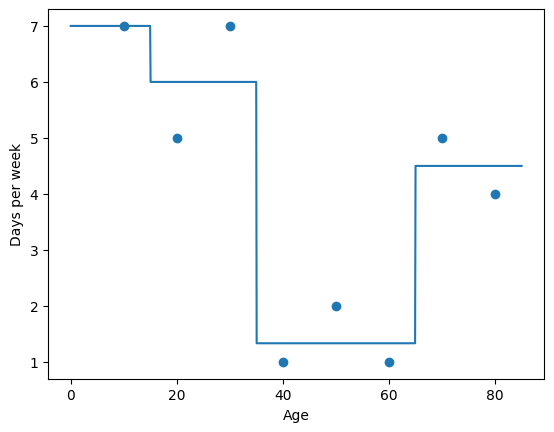

In [7]:
plot_regressor(decision_tree_regressor, features, labels)

# Gradient boosting

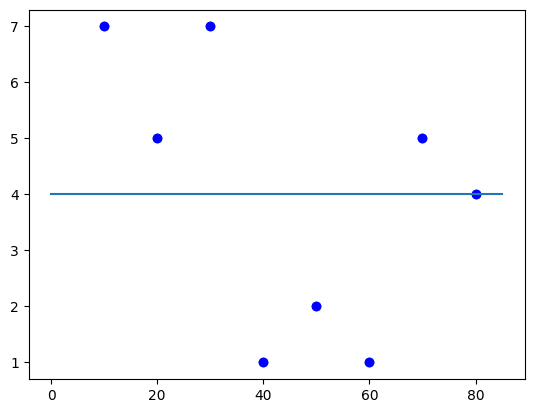

In [8]:
# First weak learner
x = np.linspace(0,85,2)
plt.scatter(features, labels)
plt.plot(x, [4 for i in range(len(x))])
plt.scatter(features, labels, color='blue')

In [9]:
gradient_boosting_regressor = GradientBoostingRegressor(max_depth=2, n_estimators=4, learning_rate=0.8)
gradient_boosting_regressor.fit(features, labels)
gradient_boosting_regressor.predict(features)

array([6.87466667, 5.11466667, 6.71466667, 1.43466667, 1.43466667,
       1.43466667, 4.896     , 4.096     ])

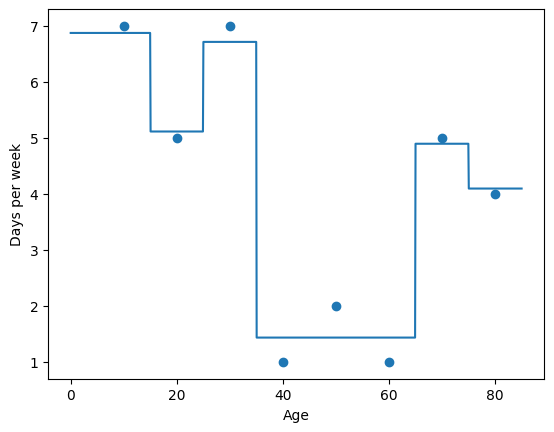

In [10]:
plot_regressor(gradient_boosting_regressor, features, labels)


**************************************************

Weak learner 1
Residuals to predict: [ 3.  1.  3. -3. -2. -3.  1.  0.]
Predictions: [ 3.          2.          2.         -2.66666667 -2.66666667 -2.66666667
  0.5         0.5       ]


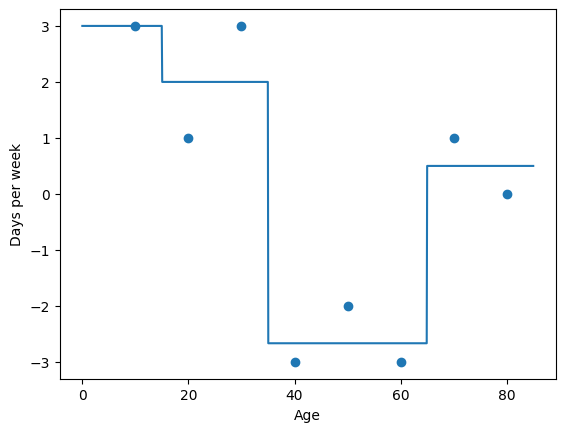

New residuals: [ 0.6        -0.6         1.4        -0.86666667  0.13333333 -0.86666667
  0.6        -0.4       ]

**************************************************

Weak learner 2
Residuals to predict: [ 0.6        -0.6         1.4        -0.86666667  0.13333333 -0.86666667
  0.6        -0.4       ]
Predictions: [ 0.          0.          1.4        -0.53333333 -0.53333333 -0.53333333
  0.1         0.1       ]


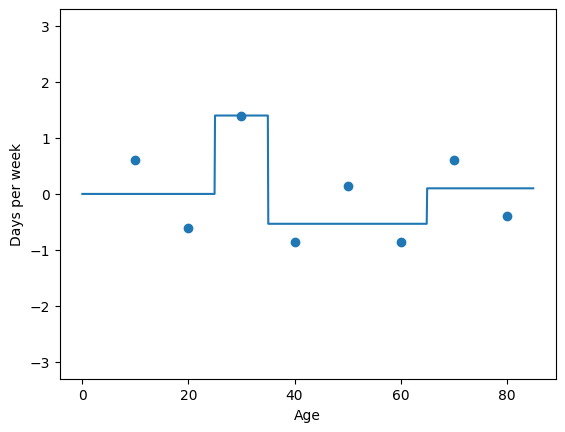

New residuals: [ 0.6  -0.6   0.28 -0.44  0.56 -0.44  0.52 -0.48]

**************************************************

Weak learner 3
Residuals to predict: [ 0.6  -0.6   0.28 -0.44  0.56 -0.44  0.52 -0.48]
Predictions: [ 6.00000000e-01 -6.00000000e-01 -7.40148683e-17 -7.40148683e-17
 -7.40148683e-17 -7.40148683e-17 -7.40148683e-17 -7.40148683e-17]


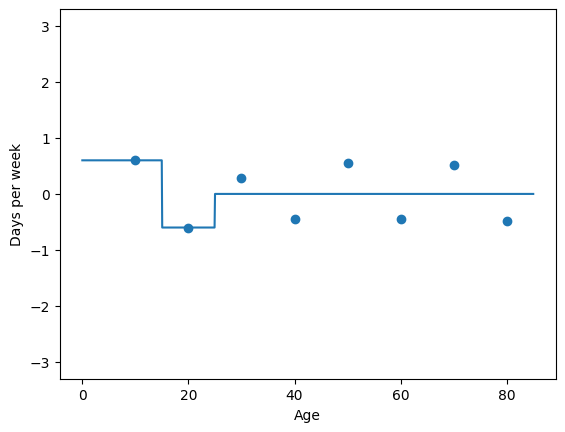

New residuals: [ 0.12 -0.12  0.28 -0.44  0.56 -0.44  0.52 -0.48]

**************************************************

Weak learner 4
Residuals to predict: [ 0.12 -0.12  0.28 -0.44  0.56 -0.44  0.52 -0.48]
Predictions: [-0.00666667 -0.00666667 -0.00666667 -0.00666667 -0.00666667 -0.00666667
  0.52       -0.48      ]


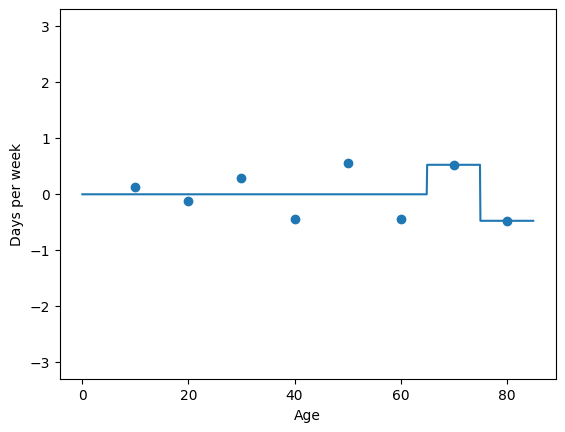

New residuals: [ 0.12533333 -0.11466667  0.28533333 -0.43466667  0.56533333 -0.43466667
  0.104      -0.096     ]


In [11]:
#manual calculation
predictions_estimators = []
predictions = np.zeros(8)
centered_labels = labels-labels.mean()
residuals = [centered_labels]
for i in range(len(gradient_boosting_regressor.estimators_)):
    weak_learner = gradient_boosting_regressor.estimators_[i][0]
    print("\n"+"*"*50+"\n")
    print("Weak learner", i+1)
    preds = weak_learner.predict(features) #Tree 1 is trying to predict the residual/error.
    predictions_estimators.append(preds)
    print("Residuals to predict:", residuals[-1])
    print("Predictions:", preds) #preds and residuals are different because on one leaf it can have 2 output and they have to calcualte the average of the residual again
    predictions += preds*0.8
    plt.scatter(features, centered_labels, color='white')
    plot_regressor(weak_learner, features, residuals[-1])
    plt.show()
    residuals.append(centered_labels-predictions)
    print("New residuals:", residuals[-1])
    #y axis is the residuals

Predictions of the first i learners

Up to weak learner number 1


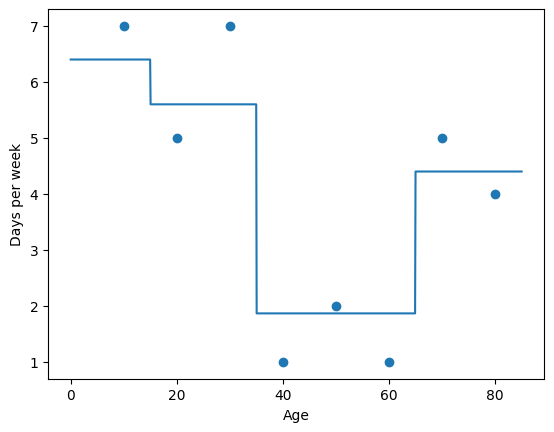

Up to weak learner number 2


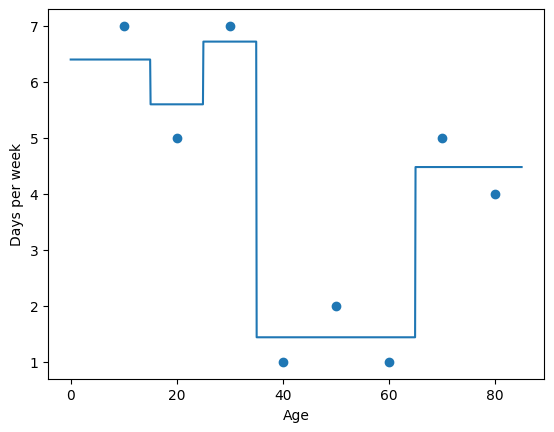

Up to weak learner number 3


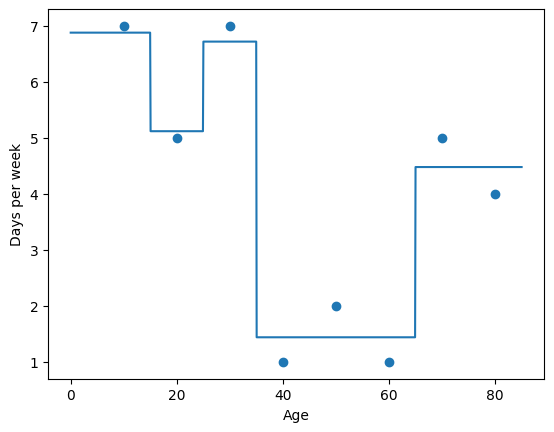

Up to weak learner number 4


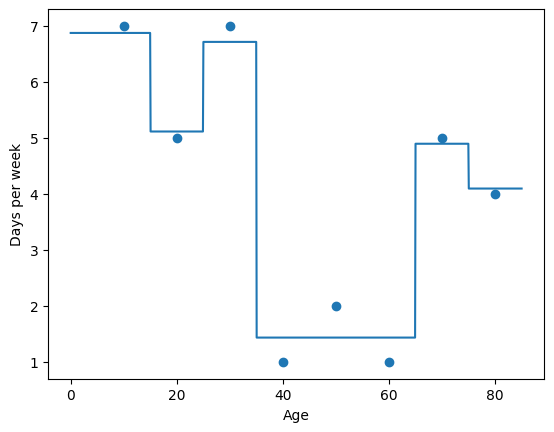

In [12]:
for i in range(1,5):
    print("Up to weak learner number", i)
    gb_intermediate = GradientBoostingRegressor(max_depth=2, n_estimators=i, learning_rate=0.8)
    gb_intermediate.fit(features, labels)
    predictions = gb_intermediate.predict(features)
    plot_regressor(gb_intermediate, features, labels)

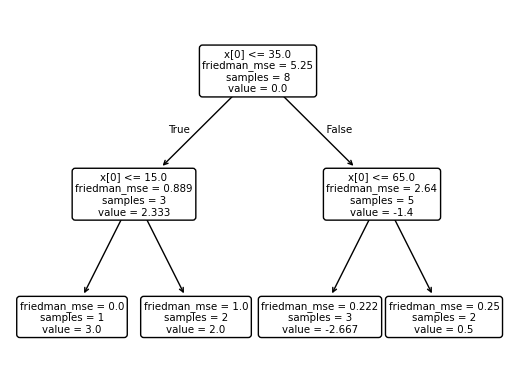

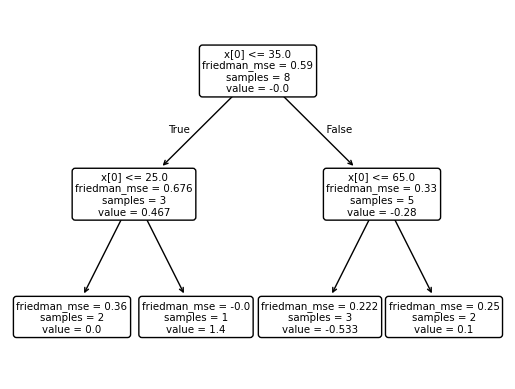

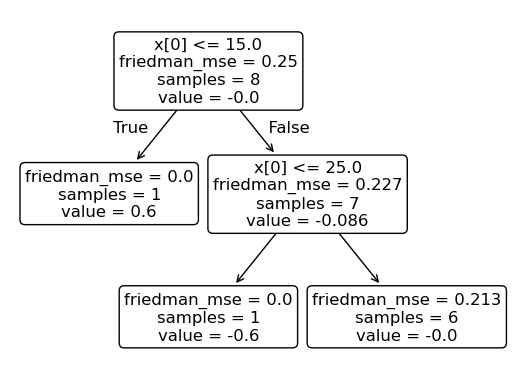

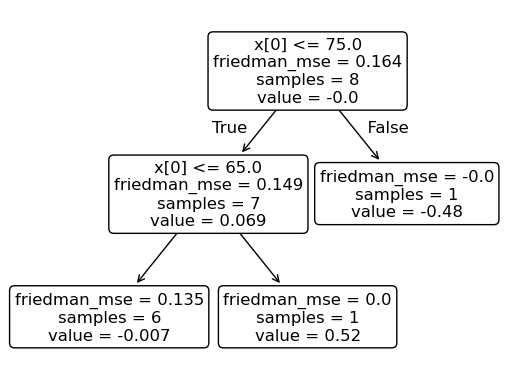

In [13]:
for tree in gradient_boosting_regressor.estimators_:
    sklearn.tree.plot_tree(tree[0], rounded=True)
    plt.show()

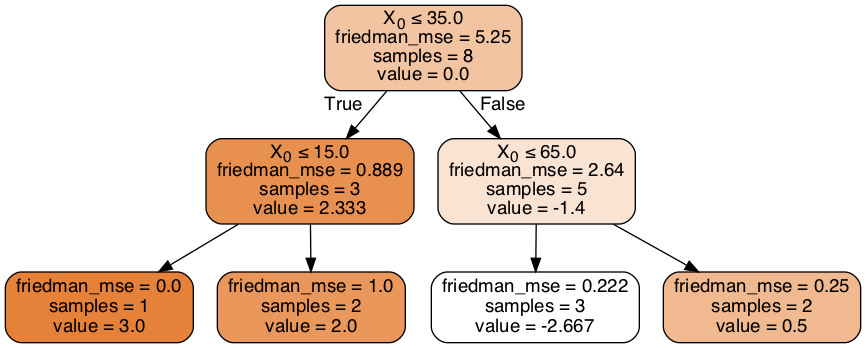

In [14]:
display_tree(gradient_boosting_regressor.estimators_[0][0])

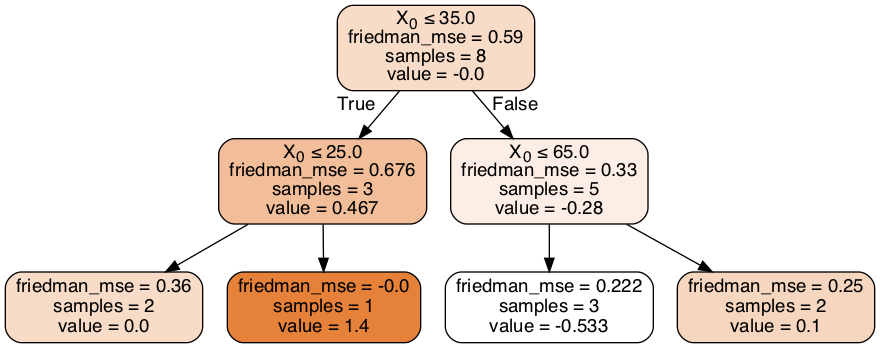

In [15]:
display_tree(gradient_boosting_regressor.estimators_[1][0])

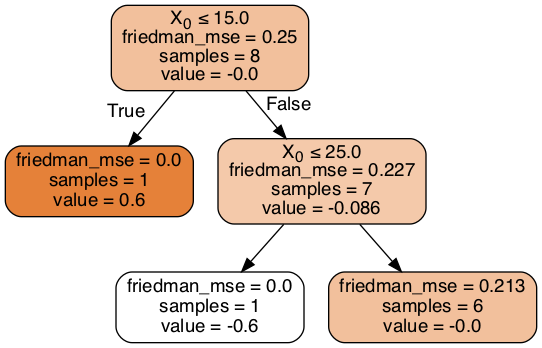

In [16]:
display_tree(gradient_boosting_regressor.estimators_[2][0])

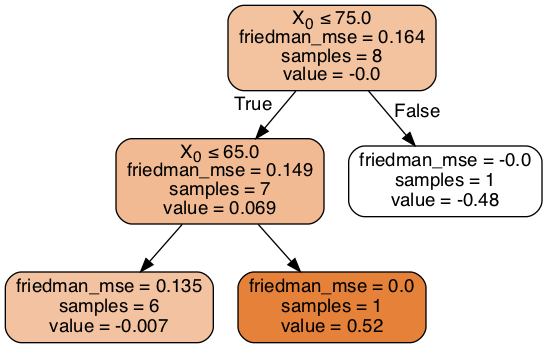

In [17]:
display_tree(gradient_boosting_regressor.estimators_[3][0])

# XGBoost

In [17]:
# Imports
import xgboost
from xgboost import XGBRegressor

In [18]:
# Let's start with an initial prediction. Since the average of the labels is 4.0, we'll use that.

initial_prediction = 4.0

In [19]:
import xgboost
from xgboost import XGBRegressor
xgboost_regressor = XGBRegressor(random_state=0,
                                 n_estimators=3,
                                 max_depth=2,
                                 reg_lambda=3,
                                 min_split_loss=2,
                                 learning_rate=0.7,
                                 base_score=initial_prediction
                                 )
xgboost_regressor.fit(features, labels)
xgboost_regressor.score(features, labels)

0.8121875524520874

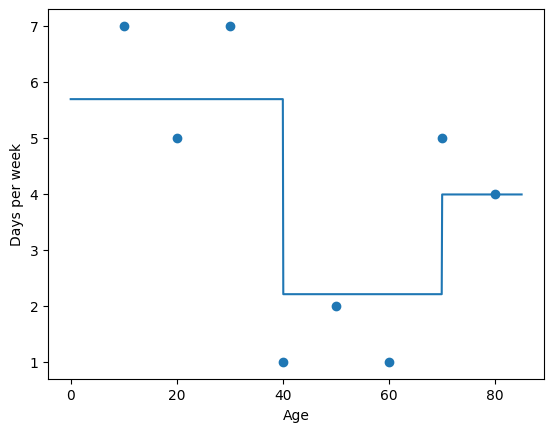

In [20]:
plot_regressor(xgboost_regressor, features, labels)

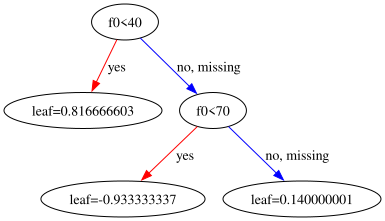

In [22]:
xgboost.to_graphviz(xgboost_regressor, num_trees=0)

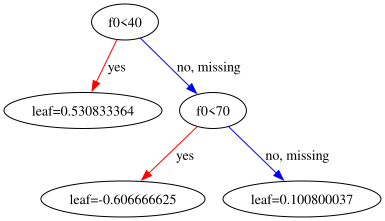

In [23]:
xgboost.to_graphviz(xgboost_regressor, num_trees=1)

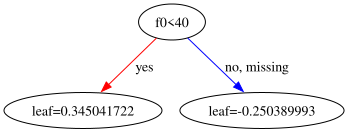

In [24]:
xgboost.to_graphviz(xgboost_regressor, num_trees=2)

In [25]:
xgboost_regressor.predict(features)

array([5.6925416, 5.6925416, 5.6925416, 2.20961  , 2.20961  , 2.20961  ,
       3.9904099, 3.9904099], dtype=float32)

In [26]:
# Prediction for age=20
4+0.816666603+0.530833364+0.345041722

5.6925416890000005

In [27]:
# Predictions for each tree
booster = xgboost_regressor.get_booster()
trees = booster.get_dump(with_stats=True)  # prints each tree as text
for tree in trees:
    print(tree)   # you'll see leaf values

0:[f0<40] yes=1,no=2,missing=2,gain=14.291667,cover=8
	1:leaf=0.816666603,cover=3
	2:[f0<70] yes=3,no=4,missing=4,gain=4.74166679,cover=5
		3:leaf=-0.933333337,cover=3
		4:leaf=0.140000001,cover=2

0:[f0<40] yes=1,no=2,missing=2,gain=5.95877075,cover=8
	1:leaf=0.530833364,cover=3
	2:[f0<70] yes=3,no=4,missing=4,gain=2.10154676,cover=5
		3:leaf=-0.606666625,cover=3
		4:leaf=0.100800037,cover=2

0:[f0<40] yes=1,no=2,missing=2,gain=2.48055959,cover=8
	1:leaf=0.345041722,cover=3
	2:leaf=-0.250389993,cover=5



# Calculations of similarity score

In [28]:
residuals = labels-initial_prediction
residuals

array([ 3.,  1.,  3., -3., -2., -3.,  1.,  0.])

In [29]:
def similarity_score(l, lam=0):
    if len(l)==0:
        return 0
    return sum(l)**2/(len(l)+lam)

In [30]:
# For this experiment, we'll pick a regularization parameter of lambda=3
# Fun fact: We can't call it lambda, as that name is taken for a function
lam = 3

In [31]:
similarity_score(residuals, lam)

np.float64(0.0)

In [32]:
def find_best_split(residuals, lam):
    root_score = similarity_score(residuals, lam)
    best_score = 0
    winning_split = [[], residuals]
    winning_left = []
    winning_right = []
    for i in range(1,len(residuals)):
        left = residuals[:i]
        right = residuals[i:]
        new_score = similarity_score(left, lam)+similarity_score(right, lam)
        print("Left tree: ", left)
        print("Right tree: ", right)
        print("Similarity score left: ",similarity_score(left, lam))
        print("Similarity score right: ",similarity_score(right, lam))
        print("Sum of similarity scores: ", new_score)
        print()
        if new_score > best_score:
            winning_split = [left, right]
            best_score = new_score
            winning_left = left
            winning_right = right
    print("*"*50)
    print()
    print("Root similarity score: ", root_score)
    print("Best split: ", winning_split)
    print("Similarity score: ", best_score)
    print("Similarity gain: ", best_score - root_score)
    return winning_left, winning_right, new_score, winning_split

In [33]:
left_tree, right_tree, _, _ = find_best_split(residuals, lam)

Left tree:  [3.]
Right tree:  [ 1.  3. -3. -2. -3.  1.  0.]
Similarity score left:  2.25
Similarity score right:  0.9
Sum of similarity scores:  3.15

Left tree:  [3. 1.]
Right tree:  [ 3. -3. -2. -3.  1.  0.]
Similarity score left:  3.2
Similarity score right:  1.7777777777777777
Sum of similarity scores:  4.977777777777778

Left tree:  [3. 1. 3.]
Right tree:  [-3. -2. -3.  1.  0.]
Similarity score left:  8.166666666666666
Similarity score right:  6.125
Sum of similarity scores:  14.291666666666666

Left tree:  [ 3.  1.  3. -3.]
Right tree:  [-2. -3.  1.  0.]
Similarity score left:  2.2857142857142856
Similarity score right:  2.2857142857142856
Sum of similarity scores:  4.571428571428571

Left tree:  [ 3.  1.  3. -3. -2.]
Right tree:  [-3.  1.  0.]
Similarity score left:  0.5
Similarity score right:  0.6666666666666666
Sum of similarity scores:  1.1666666666666665

Left tree:  [ 3.  1.  3. -3. -2. -3.]
Right tree:  [1. 0.]
Similarity score left:  0.1111111111111111
Similarity score r

We notice that using lambda=3, the best split is [3,1,3], [-3,-2,-3,1,0]

In [34]:
print("Left tree: ", left_tree)
print("Right tree: ", right_tree)

Left tree:  [3. 1. 3.]
Right tree:  [-3. -2. -3.  1.  0.]


In [35]:
find_best_split(left_tree,lam)

Left tree:  [3.]
Right tree:  [1. 3.]
Similarity score left:  2.25
Similarity score right:  3.2
Sum of similarity scores:  5.45

Left tree:  [3. 1.]
Right tree:  [3.]
Similarity score left:  3.2
Similarity score right:  2.25
Sum of similarity scores:  5.45

**************************************************

Root similarity score:  8.166666666666666
Best split:  [array([3.]), array([1., 3.])]
Similarity score:  5.45
Similarity gain:  -2.716666666666666


(array([3.]),
 array([1., 3.]),
 np.float64(5.45),
 [array([3.]), array([1., 3.])])

In [36]:
find_best_split(right_tree,lam)

Left tree:  [-3.]
Right tree:  [-2. -3.  1.  0.]
Similarity score left:  2.25
Similarity score right:  2.2857142857142856
Sum of similarity scores:  4.535714285714286

Left tree:  [-3. -2.]
Right tree:  [-3.  1.  0.]
Similarity score left:  5.0
Similarity score right:  0.6666666666666666
Sum of similarity scores:  5.666666666666667

Left tree:  [-3. -2. -3.]
Right tree:  [1. 0.]
Similarity score left:  10.666666666666666
Similarity score right:  0.2
Sum of similarity scores:  10.866666666666665

Left tree:  [-3. -2. -3.  1.]
Right tree:  [0.]
Similarity score left:  7.0
Similarity score right:  0.0
Sum of similarity scores:  7.0

**************************************************

Root similarity score:  6.125
Best split:  [array([-3., -2., -3.]), array([1., 0.])]
Similarity score:  10.866666666666665
Similarity gain:  4.741666666666665


(array([-3., -2., -3.]),
 array([1., 0.]),
 np.float64(7.0),
 [array([-3., -2., -3.]), array([1., 0.])])

Likewise, the best splits for the remaining trees are:

- Left tree: [3,1], [3] (two options here that score equally)
- Right tree: [-3,-2,-3], [1,0]

# Exploring the regularization parameter λ 

Let's train an XGBoost regressor with different values for the regularization parameter λ. We'll try λ= 1 , 10, 100.

Notice that as λ increases, the prediction gets closer and closer to the average prediction.

lambda =  0


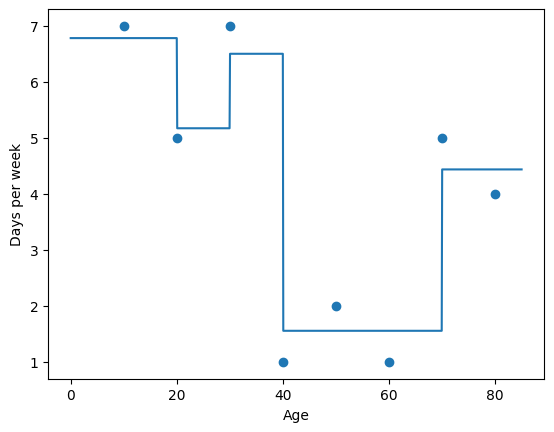

lambda =  10


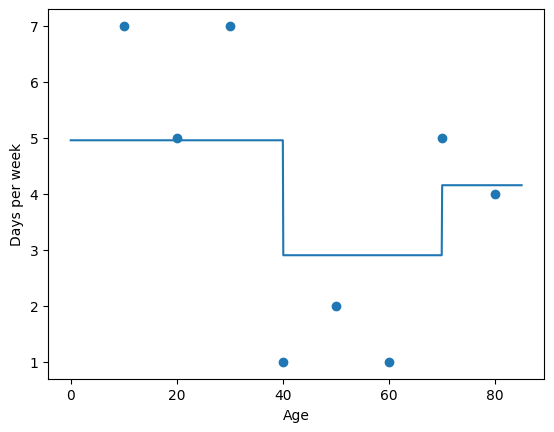

lambda =  20


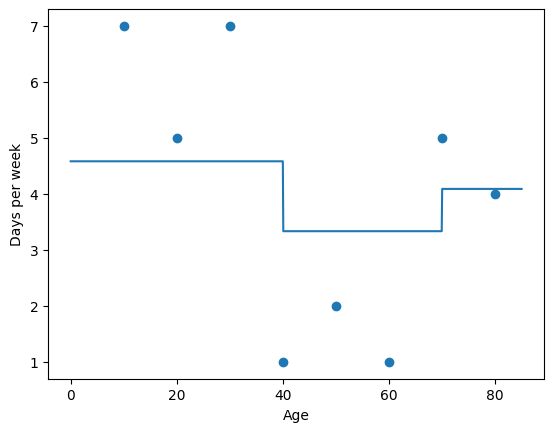

lambda =  100


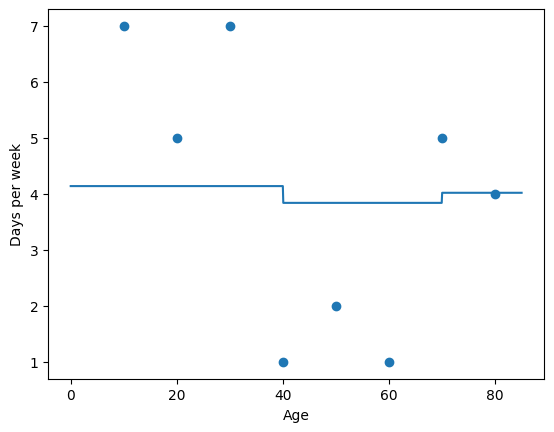

In [37]:
features = np.array([[10],[20],[30],[40],[50],[60],[70],[80]])
labels = np.array([7,5,7,1,2,1,5,4])

# Recall that our initial prediction was the average of the labels
initial_prediction = 4.0

for i in [0, 10, 20, 100]:
    print("lambda = ", i)
    xgboost_regressor = XGBRegressor(random_state=0,
                                     n_estimators=3,
                                     max_depth=2,
                                     reg_lambda=i,
                                     min_split_loss=0,
                                     learning_rate=0.7,
                                     base_score=initial_prediction)
    xgboost_regressor.fit(features, labels)
    xgboost_regressor.score(features, labels)
    plot_regressor(xgboost_regressor, features, labels)

# Exploring the similarity gain parameter γ (for pruning)

Let's train an XGBoost regressor with different values for the pruning parameter γ. We'll try γ= 1 , 10, 100.

Notice that as γ increases, the prediction gets closer and closer to the average prediction.

gamma =  0


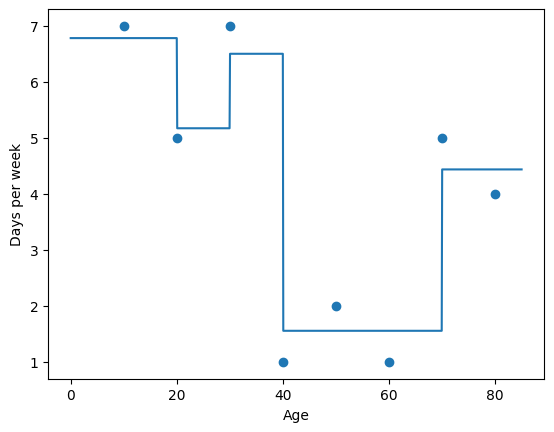

gamma =  10


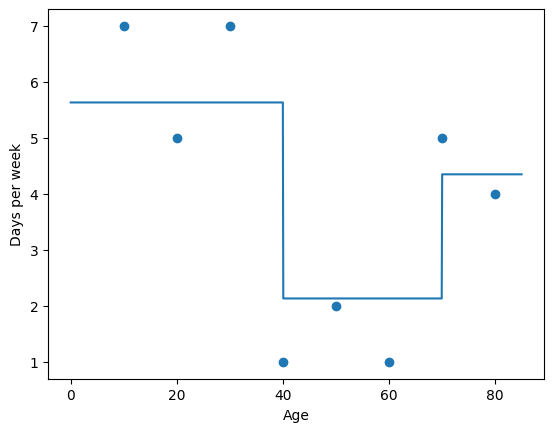

gamma =  20


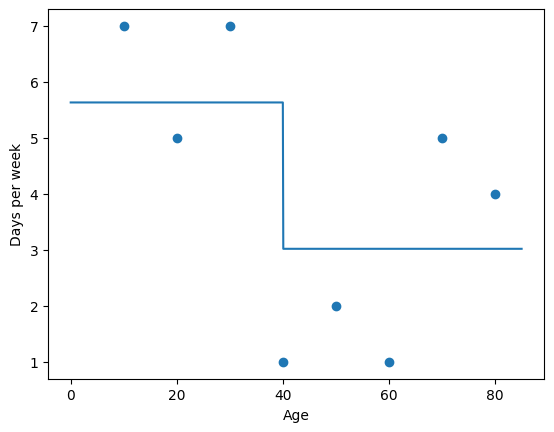

gamma =  100


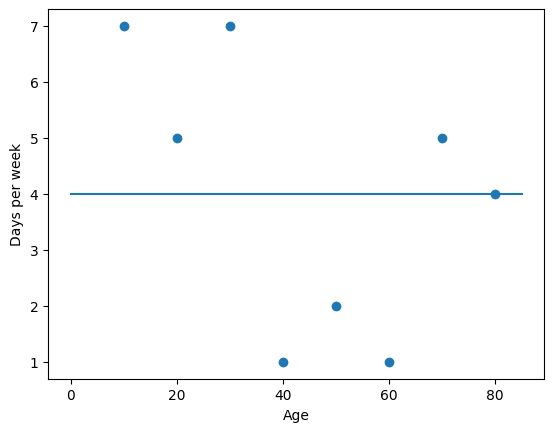

In [38]:
features = np.array([[10],[20],[30],[40],[50],[60],[70],[80]])
labels = np.array([7,5,7,1,2,1,5,4])

# Recall that our initial prediction was the average of the labels
initial_prediction = 4.0

for i in [0, 10, 20, 100]:
    print("gamma = ", i)
    xgboost_regressor = XGBRegressor(random_state=0,
                                     n_estimators=3,
                                     max_depth=2,
                                     reg_lambda=0,
                                     min_split_loss=i,
                                     learning_rate=0.7,
                                     base_score=initial_prediction)
    xgboost_regressor.fit(features, labels)
    xgboost_regressor.score(features, labels)
    plot_regressor(xgboost_regressor, features, labels)